# DS-MINI: initial 100 cycles → cycle_life

독립 구현 결과를 순서대로 검토합니다. 설계서 p5/6/13/16/18을 기준으로 작성했습니다.

**Data → Feature → M0–M4 → Model comparison → CV / tuning → Model selection → Valid → Final refit → Batch2 → Batch3 → Failure analysis**

이 Notebook은 저장된 실험을 읽으므로 external Test를 보고 다시 학습하지 않습니다. 전체 실험을 새로 실행하려면 터미널에서 `.venv/bin/python -m src.run_experiment --output outputs/new_run`을 실행하세요. 기존 `config/split_manifest.json`은 유지합니다.

In [1]:
from pathlib import Path
import sys, json
import pandas as pd
import numpy as np
from IPython.display import display, Markdown, Image
ROOT = Path.cwd() if (Path.cwd() / 'src').exists() else Path.cwd().parent
sys.path.insert(0, str(ROOT))
OUT = ROOT / 'outputs/modeling_20261002_rebuilt'
def read(name): return pd.read_csv(OUT / name)
def read_json(name): return json.loads((OUT / name).read_text())
cfg = read_json('config.json')
x = read('features.csv').set_index('cell_id')
audit = read('feature_audit.csv').set_index('cell_id')
comparison = read('candidate_comparison.csv')
perf = read('performance.csv')
selected = read_json('selected_model.json')
display(Markdown(f"프로젝트 목표 **MAPE {cfg['project_goal_mape_pct']}%**; output: `{OUT.name}`"))

프로젝트 목표 **MAPE 9.1%**; output: `modeling_20261002_rebuilt`

## 1. Data
설계서 cohort 원본 139셀에서 Target 없는 10셀만 제외합니다. 별도 VarCharge 2셀 파일은 설계서 cohort 밖입니다. Batch1에서만 개발하며 Batch2/3 Target 값은 최종 모델 동결 후 평가 전용으로 읽습니다. 초기 100 cycle의 summary만 디스크에서 읽습니다.

In [2]:
display(audit.groupby('batch').size().rename('cells').to_frame())
display(read_json('exclusions.json'))
split=read_json('split_manifest.json')
display({'Train':len(split['train']), 'Valid':len(split['valid']), 'source':split['source']})

,cells
batch,
1,46
2,39
3,44


{'excluded': [{'cell_id': 'b2c22', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c23', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c35', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c36', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c37', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c38', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c39', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b2c40', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b3c23', 'reason': 'missing_or_invalid_target'},
  {'cell_id': 'b3c32', 'reason': 'missing_or_invalid_target'}],
 'out_of_cohort_files': ['2018-04-03_varcharge_batchdata_updated_struct_errorcorrect.mat']}

{'Train': 36,
 'Valid': 10,
 'source': 'new deterministic split; no pre-existing manifest found'}

## 2. Feature
Cycle2–6 median, Cycle10–100 Theil–Sen slope, 유효 온도·IR median을 사용합니다. ΔQ는 Cycle10/100의 Qdlin을 Vdlin 기준 2.0–3.5 V 300점에 정렬하여 sample variance(ddof=1)를 log10 변환합니다. 선형 보간, 외삽 없음, 유효점≥95%, 중복 전압 없음, 간격≤0.05 V를 검증합니다.

11-cycle 이동 중앙값 대비 2% 급변은 flag만 남기며 clean 대안에서만 제외합니다. 학습 기반 imputation/scaling은 Feature 생성에 포함하지 않습니다.

In [3]:
display(audit.groupby('batch')[['initialization_rows','invalid_ir_rows','capacity_jump_count']].sum())
display(audit.groupby('batch')['dq_status'].value_counts())
display(x.describe().T)
display(x.isna().groupby(audit.batch).mean().T.mul(100).rename_axis('missing %'))

,initialization_rows,invalid_ir_rows,capacity_jump_count
batch,,,
1,46,11,2
2,0,600,8
3,0,0,0


batch  dq_status
1      ok           46
2      ok           39
3      ok           44
Name: count, dtype: int64

,count,mean,std,min,25%,50%,75%,max
log10_dq_var,129.0,-3.915359,0.428116,-5.112172,-4.177066,-3.997913,-3.514521,-3.084043
peak_c_rate,129.0,5.540310,0.816482,3.600000,5.000000,5.400000,5.900000,8.000000
switch_soc,129.0,49.519380,20.850697,9.000000,31.000000,50.000000,67.000000,80.000000
qd_initial_median,129.0,1.079173,0.014517,1.047938,1.068769,1.077600,1.090640,1.110096
qd_slope_10_100,129.0,-0.000014,0.000050,-0.000205,-0.000025,-0.000016,-0.000003,0.000114
tavg_median_100,129.0,33.216404,1.317711,29.847548,32.246488,33.092246,33.865297,36.771356
ir_median_100,123.0,0.016097,0.000909,0.013436,0.015399,0.016204,0.016681,0.019886
qd_initial_median_clean,129.0,1.079173,0.014517,1.047938,1.068769,1.077600,1.090640,1.110096
qd_slope_10_100_clean,129.0,-0.000014,0.000050,-0.000205,-0.000025,-0.000016,-0.000003,0.000114
dq_min,129.0,-0.037051,0.017827,-0.086145,-0.052547,-0.029919,-0.024193,-0.005600


batch,1,2,3
missing %,,,
log10_dq_var,0.0,0.000000,0.0
peak_c_rate,0.0,0.000000,0.0
switch_soc,0.0,0.000000,0.0
qd_initial_median,0.0,0.000000,0.0
qd_slope_10_100,0.0,0.000000,0.0
tavg_median_100,0.0,0.000000,0.0
ir_median_100,0.0,15.384615,0.0
qd_initial_median_clean,0.0,0.000000,0.0
qd_slope_10_100_clean,0.0,0.000000,0.0


## 3. M0–M4
16개 원본 후보와 clean 2개를 보존하되 모델에는 지정된 Feature 세트만 사용합니다. M0는 raw Train cycle_life median 하나이며 로그 baseline 중복은 만들지 않습니다.

In [4]:
display(pd.DataFrame([{'set':k,'features':', '.join(v),'n_features':len(v)} for k,v in read_json('feature_sets.json').items()]))

,set,features,n_features
0,M0,,0
1,M1,log10_dq_var,1
2,M2,"log10_dq_var, peak_c_rate, switch_soc",3
3,M3,"log10_dq_var, peak_c_rate, switch_soc, qd_init...",5
4,M4,"log10_dq_var, peak_c_rate, switch_soc, qd_init...",7
5,M3_clean,"log10_dq_var, peak_c_rate, switch_soc, qd_init...",5
6,M4_clean,"log10_dq_var, peak_c_rate, switch_soc, qd_init...",7


## 4. Model comparison
Linear Regression, Ridge, ElasticNet, 얕은 RandomForest, 제한된 XGBoost/LightGBM을 raw/log10 Target 각각 비교합니다. 동일 후보의 Hyperparameter는 작은 grid에서 동일 Group CV로 탐색합니다. M1–M4와 clean 대안 모두 비교하며 실패한 후보를 조용히 생략하지 않습니다.

In [5]:
display(comparison.sort_values('cv_mape_mean')[['candidate_id','feature_count','params','cv_mape_mean','cv_mape_std','cv_mae_mean','cell_cv_mape_mean']])
display(read('feature_set_comparison.csv'))

,candidate_id,feature_count,params,cv_mape_mean,cv_mape_std,cv_mae_mean,cell_cv_mape_mean
10,M1_log10_RandomForest,1,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",8.100104,3.214722,68.116803,8.483359
26,M3_raw_Ridge,5,"{""alpha"": 1.0}",8.134263,1.472604,72.280672,8.107191
50,M3_clean_raw_Ridge,5,"{""alpha"": 1.0}",8.136027,1.476840,72.288170,8.109589
4,M1_raw_RandomForest,1,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",8.255521,3.512075,69.058032,8.749893
27,M3_raw_ElasticNet,5,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",8.280443,1.615529,74.155621,8.106320
...,...,...,...,...,...,...,...
54,M3_clean_raw_LightGBM,5,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.275656,4.488691,93.840041,10.825254
30,M3_raw_LightGBM,5,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.275656,4.488691,93.840041,10.825254
66,M4_clean_raw_LightGBM,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.612818,3.936130,95.844457,10.942543
42,M4_raw_LightGBM,7,"{""learning_rate"": 0.03, ""max_depth"": 2, ""min_c...",11.612818,3.936130,95.844457,10.942543


,candidate_id,feature_set,features,feature_count,model,target,params,cv_mape_mean,cv_mape_std,cv_mae_mean,cv_oof_mape,cell_cv_mape_mean,cell_cv_mape_std
0,M1_log10_RandomForest,M1,['log10_dq_var'],1,RandomForest,log10,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",8.100104,3.214722,68.116803,8.171985,8.483359,3.202362
1,M3_raw_Ridge,M3,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",5,Ridge,raw,"{""alpha"": 1.0}",8.134263,1.472604,72.280672,8.093068,8.107191,2.013517
2,M3_clean_raw_Ridge,M3_clean,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",5,Ridge,raw,"{""alpha"": 1.0}",8.136027,1.476840,72.288170,8.094778,8.109589,2.012815
3,M2_log10_RandomForest,M2,"['log10_dq_var', 'peak_c_rate', 'switch_soc']",3,RandomForest,log10,"{""max_depth"": 2, ""max_features"": 1.0, ""min_sam...",8.328433,3.668989,69.671305,8.393170,8.491816,3.153345
4,M4_log10_RandomForest,M4,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",7,RandomForest,log10,"{""max_depth"": 3, ""max_features"": 1.0, ""min_sam...",8.474918,3.778863,71.170114,8.521834,9.121564,4.228377
5,M4_clean_log10_RandomForest,M4_clean,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",7,RandomForest,log10,"{""max_depth"": 3, ""max_features"": 1.0, ""min_sam...",8.474918,3.778863,71.170114,8.521834,9.121564,4.228377
6,M0_raw_Dummy,M0,[],0,Dummy,raw,{},19.755897,6.141806,155.314286,19.629822,21.044771,5.555409


## 5. CV / tuning
충전 protocol (C1, switch SOC, C2)을 group으로 사용합니다. newstructure 태그는 group을 분리하지 않습니다. Group CV는 평가 fold와 학습 fold에 동일 protocol이 나타나지 않도록 합니다. Cell CV는 보조 확인입니다.

각 fold에서 MedianImputer → StandardScaler(선형만) → model을 새로 학습합니다. TransformedTargetRegressor에서 log10 Target과 inverse를 처리합니다. 후보 튜닝 CV 점수에는 선택 낙관 편향이 있으므로 전체 선택 과정도 nested Group CV로 평가합니다.

In [6]:
folds=read_json('cv_folds.json')
display(pd.DataFrame([{'fold':f['fold'],'train_n':len(f['train_ids']),'valid_n':len(f['valid_ids']), 'group_overlap':len(set(audit.loc[f['train_ids'],'protocol_group']) & set(audit.loc[f['valid_ids'],'protocol_group']))} for f in folds]))
display(read('hyperparameter_trials.csv').sort_values('cv_mape_mean').head(15))
nested=read('nested_cv_results.csv')
display(nested)
display({'nested_mean_mape_pct':nested.mape_pct.mean(),'nested_std_pp':nested.mape_pct.std()})

,fold,train_n,valid_n,group_overlap
0,0,28,8,0
1,1,29,7,0
2,2,29,7,0
3,3,29,7,0
4,4,29,7,0


,candidate_id,feature_set,features,feature_count,model,target,params,cv_mape_mean,cv_mape_std,cv_mae_mean,cv_oof_mape
53,M1_log10_RandomForest,M1,['log10_dq_var'],1,RandomForest,log10,"{""max_depth"": 2, ""max_features"": 0.7, ""min_sam...",8.100104,3.214722,68.116803,8.171985
55,M1_log10_RandomForest,M1,['log10_dq_var'],1,RandomForest,log10,"{""max_depth"": 2, ""max_features"": 1.0, ""min_sam...",8.100104,3.214722,68.116803,8.171985
156,M3_raw_Ridge,M3,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",5,Ridge,raw,"{""alpha"": 1.0}",8.134263,1.472604,72.280672,8.093068
308,M3_clean_raw_Ridge,M3_clean,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",5,Ridge,raw,"{""alpha"": 1.0}",8.136027,1.476840,72.288170,8.094778
57,M1_log10_RandomForest,M1,['log10_dq_var'],1,RandomForest,log10,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",8.186772,3.367996,68.831556,8.264757
59,M1_log10_RandomForest,M1,['log10_dq_var'],1,RandomForest,log10,"{""max_depth"": 3, ""max_features"": 1.0, ""min_sam...",8.186772,3.367996,68.831556,8.264757
19,M1_raw_RandomForest,M1,['log10_dq_var'],1,RandomForest,raw,"{""max_depth"": 3, ""max_features"": 0.7, ""min_sam...",8.255521,3.512075,69.058032,8.340332
21,M1_raw_RandomForest,M1,['log10_dq_var'],1,RandomForest,raw,"{""max_depth"": 3, ""max_features"": 1.0, ""min_sam...",8.255521,3.512075,69.058032,8.340332
161,M3_raw_ElasticNet,M3,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",5,ElasticNet,raw,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",8.280443,1.615529,74.155621,8.230609
313,M3_clean_raw_ElasticNet,M3_clean,"['log10_dq_var', 'peak_c_rate', 'switch_soc', ...",5,ElasticNet,raw,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",8.281414,1.617907,74.155548,8.231551


,fold,candidate_id,params,mape_pct,mae,mean_signed_error,overprediction_rate_pct
0,0,M2_raw_ElasticNet,"{""alpha"": 0.01, ""l1_ratio"": 0.2}",8.988046,74.243824,5.445140,62.500000
1,1,M3_clean_raw_Ridge,"{""alpha"": 0.01}",8.801457,83.771782,-12.225974,71.428571
2,2,M3_log10_Ridge,"{""alpha"": 1.0}",7.107337,50.561374,25.516348,71.428571
3,3,M2_log10_Linear,{},15.096277,155.546428,155.546428,100.000000
4,4,M2_raw_Ridge,"{""alpha"": 1.0}",9.747720,85.299297,-71.941757,28.571429


{'nested_mean_mape_pct': np.float64(9.94816740544289),
 'nested_std_pp': np.float64(3.0352228409888125)}

## 6. Model selection
선택 규칙을 평가 전에 고정합니다. Group CV 최저 평균 MAPE + 0.5%p 이내 → 적은 Feature 수 → 낮은 fold 편차 → 모델 복잡도 → 평균 MAPE → 후보 ID. Valid나 외부 Test 결과로 변경하지 않습니다.

In [7]:
display(cfg['selection'])
display(selected)
display(read_json('event_log.json'))

'Group CV mean MAPE within 0.5 percentage points of best: fewer features, lower fold std, complexity, mean MAPE, candidate ID; Valid once without reselection'

{'candidate_id': 'M1_log10_RandomForest',
 'feature_set': 'M1',
 'features': ['log10_dq_var'],
 'feature_count': 1,
 'model': 'RandomForest',
 'target': 'log10',
 'params': '{"max_depth": 2, "max_features": 0.7, "min_samples_leaf": 3, "n_estimators": 100}',
 'cv_mape_mean': 8.100103701305375,
 'cv_mape_std': 3.214722250998648,
 'cv_mae_mean': 68.116803233129,
 'cv_oof_mape': 8.171985352154724,
 'cell_cv_mape_mean': 8.483359358654269,
 'cell_cv_mape_std': 3.20236195312436}

[{'event': 'rules_frozen',
  'utc': '2026-10-02T06:26:23.316709+00:00',
  'config_sha256': '43edfb778fafd86414607236a48592d6b9e224d09e72c157b3374fe648c21b34'},
 {'event': 'features_prepared',
  'utc': '2026-10-02T06:26:23.738594+00:00',
  'core_missing_n': 0},
 {'event': 'candidate_frozen',
  'utc': '2026-10-02T06:26:42.569219+00:00',
  'selection_sha256': '33de421bd7f2c768a8909dae17fbeeaa50ca0e3775c764617aad7c2500c4a5a1',
  'candidate_id': 'M1_log10_RandomForest'},
 {'event': 'valid_labels_evaluated',
  'utc': '2026-10-02T06:28:06.177637+00:00',
  'candidate_unchanged': True},
 {'event': 'final_model_frozen',
  'utc': '2026-10-02T06:28:09.359535+00:00',
  'model_sha256': '5edb20ddc15c000685612bad69fc12a1cfbcd8864bde4e47d01e797138008e6c'},
 {'event': 'external_labels_loaded',
  'utc': '2026-10-02T06:28:09.362753+00:00',
  'batch': 2},
 {'event': 'external_labels_loaded',
  'utc': '2026-10-02T06:28:09.368931+00:00',
  'batch': 3},
 {'event': 'reporting_complete', 'utc': '2026-10-02T06:2

## 7. Valid
선택된 후보를 Train36에 학습하고 Holdout10에서 한 번 확인합니다. CV와 차이는 진단으로 기록하며 Hyperparameter를 다시 수정하지 않습니다.

In [8]:
display(perf[perf.partition.isin(['Train','Valid'])])
display(read('performance_gaps.csv'))

,partition,n,mape_pct,mae,mean_signed_error,overprediction_rate_pct,baseline_mape_pct
0,Train,36,8.171985,68.669893,-9.571368,44.444444,19.629822
1,Valid,10,13.792403,118.557341,62.888257,50.000000,13.682650


,gap,value_pp
0,Valid - Train,5.620418
1,Test - Valid,17.516450
2,Test - project goal,22.208853


## 8. Final refit
동일 Feature, Pipeline, Target, Hyperparameter로 Batch1 전체 46셀에 학습해 final_model.joblib을 저장합니다. 모델과 선택 해시를 고정한 다음 외부 Target을 읽습니다.

In [9]:
frozen=read_json('experiment_frozen.json')
display({k:frozen[k] for k in ['final_training_n','selection_sha256','final_model_sha256','external_target_used_for_selection','versions']})

{'final_training_n': 46,
 'selection_sha256': '33de421bd7f2c768a8909dae17fbeeaa50ca0e3775c764617aad7c2500c4a5a1',
 'final_model_sha256': '5edb20ddc15c000685612bad69fc12a1cfbcd8864bde4e47d01e797138008e6c',
 'external_target_used_for_selection': False,
 'versions': {'numpy': '2.4.6',
  'pandas': '3.0.6',
  'scikit-learn': '1.9.1',
  'xgboost': '3.2.0',
  'lightgbm': '4.7.0',
  'h5py': '3.16.0'}}

## 9. Batch2 Test
최종 model을 그대로 적용합니다. 비교 median baseline은 최종 학습 Batch1 전체 median입니다.

In [10]:
display(perf[perf.partition=='Batch2'])
pred=read('predictions.csv')
display(pred[pred.partition=='Batch2'].sort_values('ape_pct',ascending=False))

,partition,n,mape_pct,mae,mean_signed_error,overprediction_rate_pct,baseline_mape_pct
2,Batch2,39,31.308853,153.757208,147.241247,94.871795,72.656457


,cell_id,partition,actual,predicted,signed_error,absolute_error,ape_pct,baseline_prediction
52,b2c6,Batch2,393.0,627.089459,234.089459,234.089459,59.564748,858.5
64,b2c18,Batch2,449.0,696.788551,247.788551,247.788551,55.186760,858.5
65,b2c19,Batch2,392.0,603.919043,211.919043,211.919043,54.060980,858.5
61,b2c15,Batch2,396.0,606.253964,210.253964,210.253964,53.094435,858.5
67,b2c21,Batch2,408.0,603.919043,195.919043,195.919043,48.019373,858.5
74,b2c30,Batch2,412.0,603.919043,191.919043,191.919043,46.582292,858.5
51,b2c5,Batch2,416.0,603.919043,187.919043,187.919043,45.172847,858.5
48,b2c2,Batch2,424.0,603.919043,179.919043,179.919043,42.433736,858.5
75,b2c31,Batch2,425.0,603.919043,178.919043,178.919043,42.098598,858.5
60,b2c14,Batch2,426.0,603.919043,177.919043,177.919043,41.765033,858.5


## 10. Batch3 additional Test
Batch2 결과를 보고 모델을 바꾸지 않고 동일 모델을 적용합니다.

In [11]:
display(perf[perf.partition=='Batch3'])
display(pred[pred.partition=='Batch3'].sort_values('ape_pct',ascending=False).head(10))

,partition,n,mape_pct,mae,mean_signed_error,overprediction_rate_pct,baseline_mape_pct
3,Batch3,44,12.899914,155.504236,-68.363485,47.727273,20.200748


,cell_id,partition,actual,predicted,signed_error,absolute_error,ape_pct,baseline_prediction
121,b3c38,Batch3,1935.0,1107.336400,-827.663600,827.663600,42.773313,858.5
123,b3c40,Batch3,796.0,1101.458768,305.458768,305.458768,38.374217,858.5
92,b3c7,Batch3,1836.0,1143.942357,-692.057643,692.057643,37.693771,858.5
128,b3c45,Batch3,1801.0,1143.942357,-657.057643,657.057643,36.482934,858.5
124,b3c41,Batch3,786.0,1054.996400,268.996400,268.996400,34.223461,858.5
125,b3c42,Batch3,1642.0,1107.336400,-534.663600,534.663600,32.561730,858.5
101,b3c16,Batch3,1638.0,1143.942357,-494.057643,494.057643,30.162249,858.5
115,b3c31,Batch3,731.0,878.460478,147.460478,147.460478,20.172432,858.5
120,b3c37,Batch3,1390.0,1143.942357,-246.057643,246.057643,17.701989,858.5
108,b3c24,Batch3,825.0,970.829881,145.829881,145.829881,17.676349,858.5


## 11. Failure analysis
Feature shift, 학습 범위 밖 비율, 실제/예측 plot, signed error, 과대/과소 방향, Feature 추가의 내부 CV 기여를 점검합니다. 범위 이탈은 유효 Feature 관측을 분모로 사용하고 결측 비율은 별도로 보고합니다.

RandomForest의 예측은 학습 Target 범위 내에 제한되므로 단수명/장수명 외삽에 한계가 있습니다. 더 높은 Test 점수를 위해 다른 후보를 재선택하지 않습니다. Linear 최종 모델일 경우 계수와 기여도 파일이 추가됩니다.

,batch,feature,selected,n,valid_n,missing_rate_pct,minimum,maximum,median,q25,q75,batch1_min,batch1_max,below_batch1_pct,above_batch1_pct,outside_batch1_pct,wasserstein_distance
0,1,log10_dq_var,True,46,46,0.0,-5.013578,-3.348682,-3.849456,-4.052615,-3.666206,-5.013578,-3.348682,0.000000,0.000000,0.000000,0.000000
1,2,log10_dq_var,True,39,39,0.0,-4.447099,-3.084043,-3.485534,-3.672300,-3.333743,-5.013578,-3.348682,0.000000,28.205128,28.205128,0.340419
2,3,log10_dq_var,True,44,44,0.0,-5.112172,-3.449825,-4.173546,-4.322342,-4.063975,-5.013578,-3.348682,2.272727,0.000000,2.272727,0.287339


,any_outside_rate,missing_feature_mean
batch,,
1,0.000000,0.0
2,0.282051,0.0
3,0.022727,0.0


,feature_set,model,target,cv_mape_mean,previous_cv_mape,improvement_pp
0,M1,Linear,raw,9.288457,NaN,NaN
1,M1,Ridge,raw,9.289190,NaN,NaN
2,M1,ElasticNet,raw,9.288500,NaN,NaN
3,M1,RandomForest,raw,8.255521,NaN,NaN
4,M1,XGBoost,raw,10.480913,NaN,NaN
5,M1,LightGBM,raw,11.064607,NaN,NaN
6,M1,Linear,log10,10.955819,NaN,NaN
7,M1,Ridge,log10,10.956130,NaN,NaN
8,M1,ElasticNet,log10,10.955989,NaN,NaN
9,M1,RandomForest,log10,8.100104,NaN,NaN


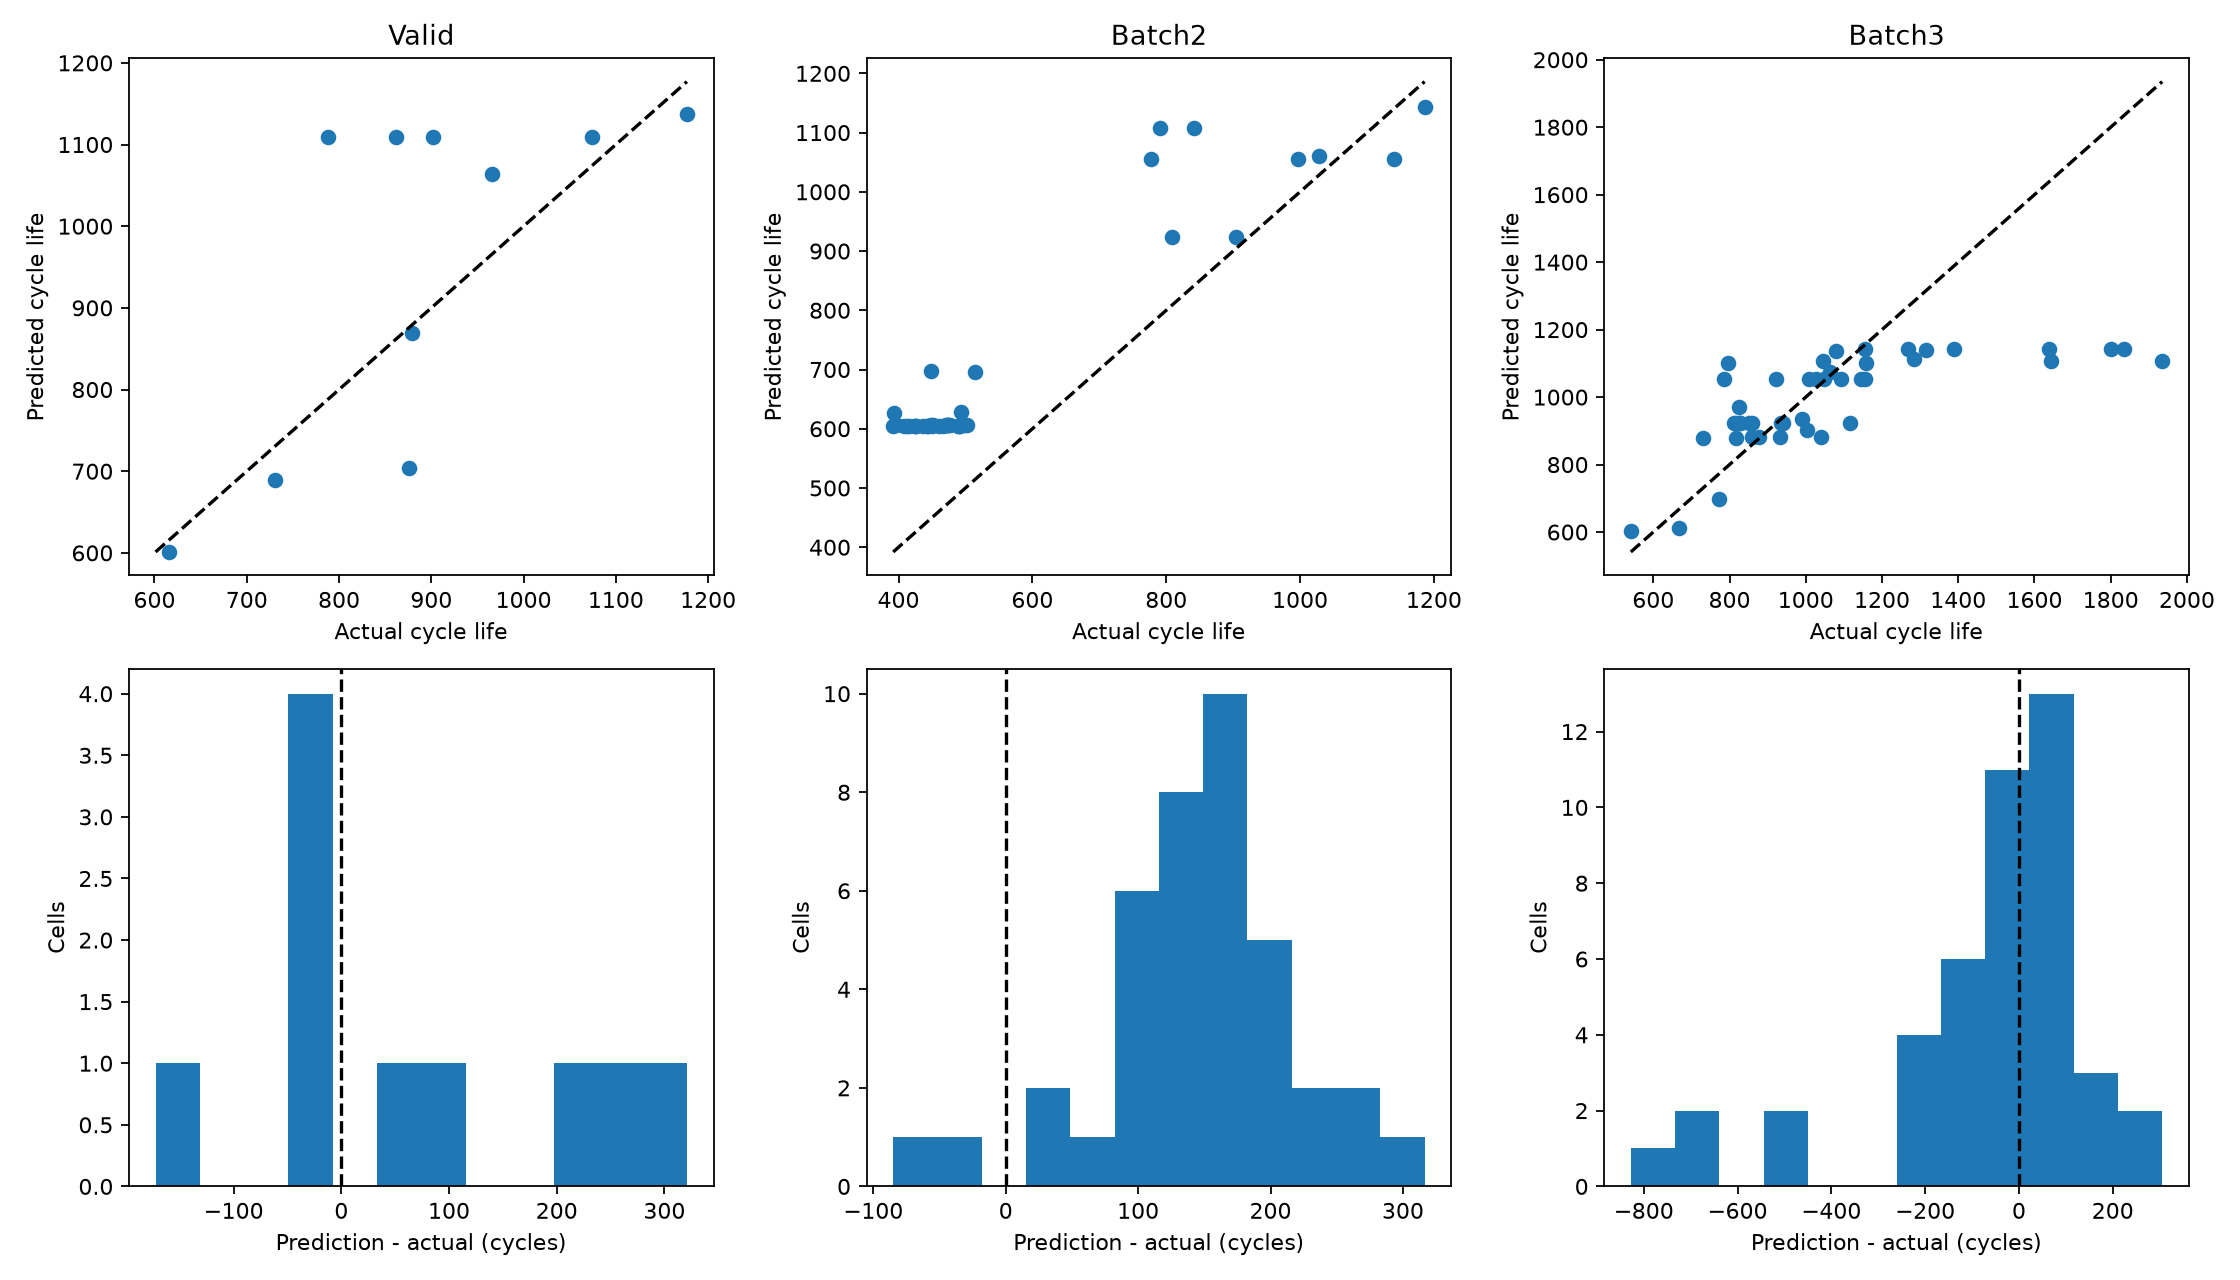

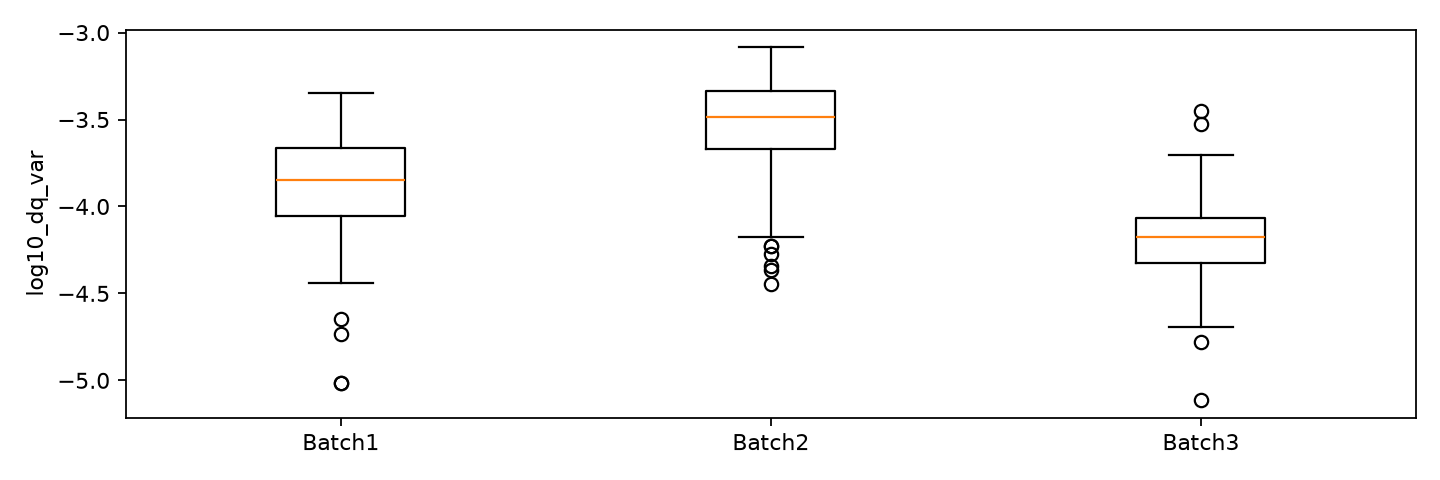

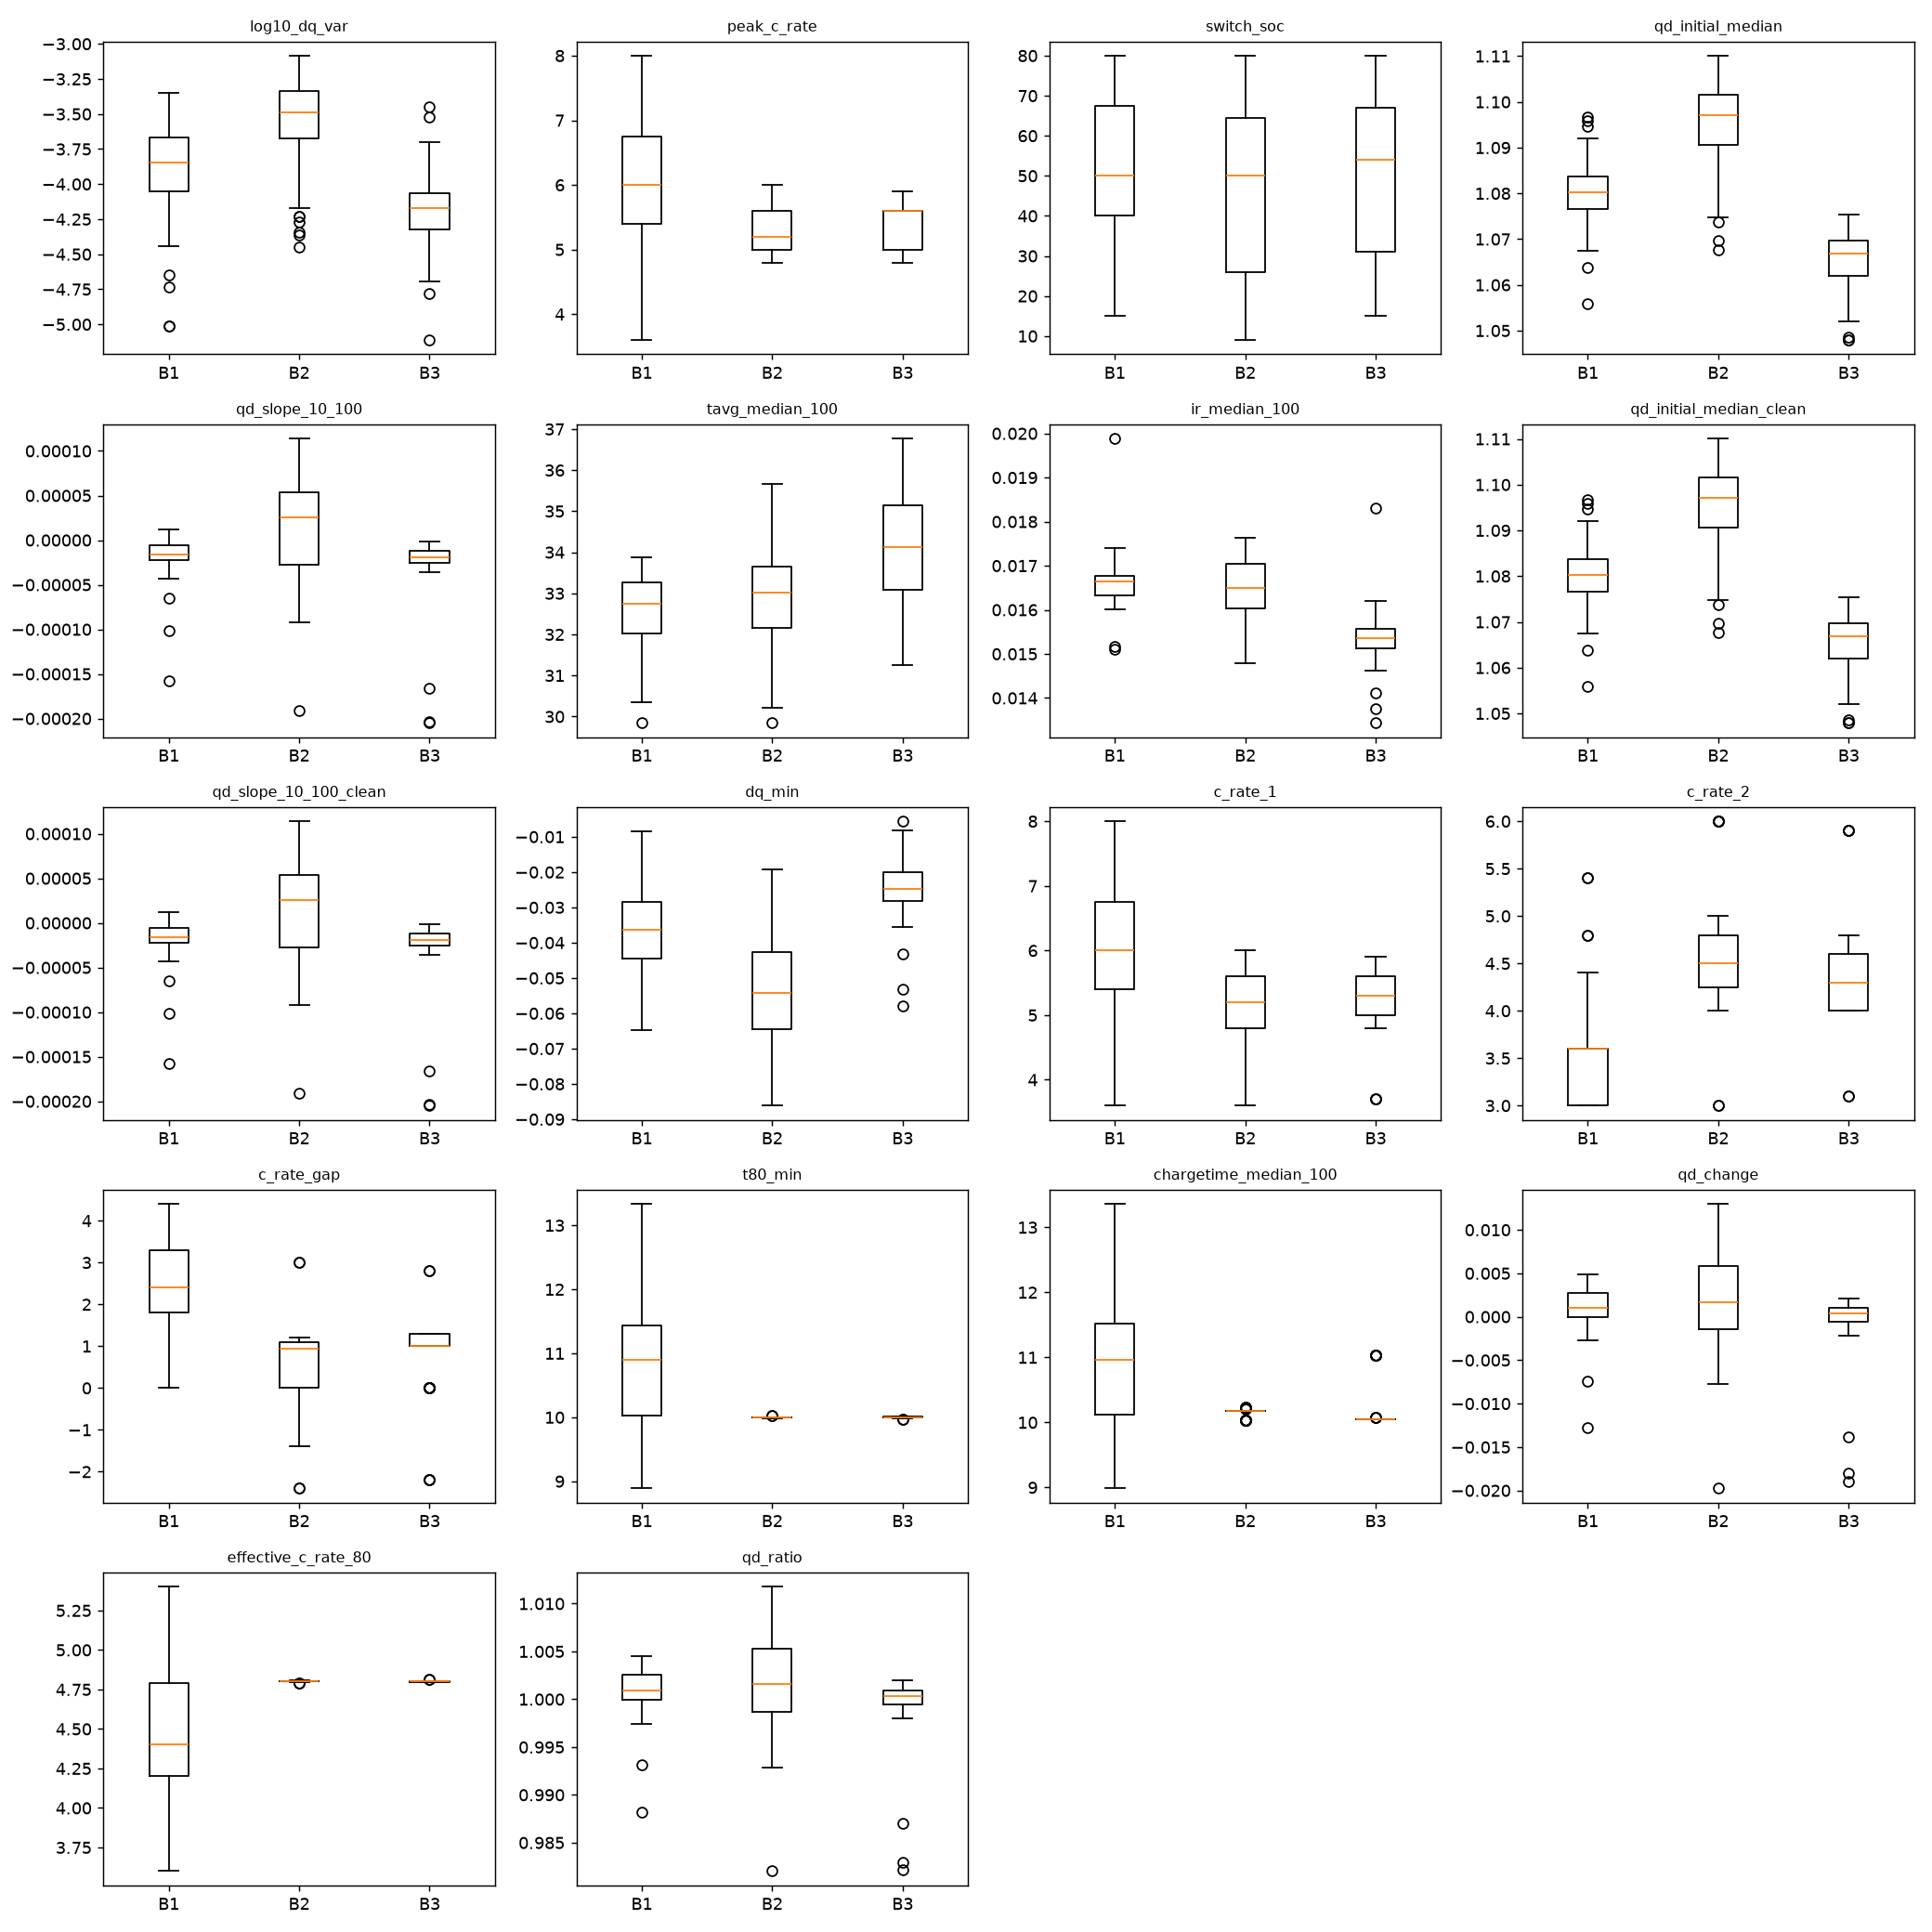

In [12]:
distribution=read('feature_distribution.csv')
display(distribution[distribution.selected])
flags=read('input_range_flags.csv')
display(flags.groupby('batch').agg(any_outside_rate=('any_outside','mean'),missing_feature_mean=('missing_feature_count','mean')))
display(read('feature_addition_effects.csv')[['feature_set','model','target','cv_mape_mean','previous_cv_mape','improvement_pp']])
display(Image(filename=str(OUT/'prediction_diagnostics.png')))
display(Image(filename=str(OUT/'feature_distributions.png')))
display(Image(filename=str(OUT/'all_feature_distributions.png')))
if (OUT/'linear_coefficients.csv').exists(): display(read('linear_coefficients.csv'))

## 12. Verification / report
셀 ID, split, X/y, cycle 관측 범위, group 분리, MAPE 수식, 로그 역변환, model reload, 동결 순서를 독립적으로 검증합니다. 검증 코드의 가드 사용을 위해 Python을 `-O` 모드로 실행하지 마세요.

In [13]:
from src.verify_results import verify_pipeline
display(verify_pipeline(OUT))
display(Markdown((OUT/'performance_report.md').read_text()))

{'passed': True,
 'checks': ['unique IDs',
  'aligned X/y',
  'batch counts',
  '36/10 disjoint split',
  'cycle <=100',
  'input allowlist',
  'protocol group isolation',
  'finite predictions',
  'MAPE independently recomputed',
  'log10 inverse roundtrip',
  'saved model reload predictions',
  'selection/model frozen before external evaluation'],
 'selection_sha256': '33de421bd7f2c768a8909dae17fbeeaa50ca0e3775c764617aad7c2500c4a5a1',
 'model_sha256': '5edb20ddc15c000685612bad69fc12a1cfbcd8864bde4e47d01e797138008e6c'}

# DS-MINI independent implementation report



설계서 p5/6/13/16/18의 관측 제한, Feature 정의, M0–M4, Pipeline 및 평가 순서를 준수합니다.

Group CV 중심 선택은 사용자의 추가 요구를 적용했습니다. Batch2/3 수명 값은 선택과 최종 refit 뒤에 평가 전용으로 읽었습니다.



## Selection

Selected: **M1_log10_RandomForest**, parameters `{"max_depth": 2, "max_features": 0.7, "min_samples_leaf": 3, "n_estimators": 100}`.

Rule fixed before evaluation: Group CV mean MAPE within 0.5 percentage points of best: fewer features, lower fold std, complexity, mean MAPE, candidate ID; Valid once without reselection

Valid 확인 뒤 후보 변경 없음. External test 후 후보 변경 없음.



## Performance (MAPE %, other errors in cycles)

| partition | n | mape_pct | mae | mean_signed_error | overprediction_rate_pct | baseline_mape_pct |
| --- | --- | --- | --- | --- | --- | --- |
| Train | 36 | 8.172 | 68.670 | -9.571 | 44.444 | 19.630 |
| Valid | 10 | 13.792 | 118.557 | 62.888 | 50.000 | 13.683 |
| Batch2 | 39 | 31.309 | 153.757 | 147.241 | 94.872 | 72.656 |
| Batch3 | 44 | 12.900 | 155.504 | -68.363 | 47.727 | 20.201 |



Train은 선택된 고정 후보의 Group CV OOF 지표입니다. CV 평균/표준편차와 pooled OOF MAPE는 서로 다를 수 있습니다.

선택 CV fold 평균=8.100%, 표준편차=3.215%p.

전체 선택 절차의 nested Group CV fold 평균=9.948%, 표준편차=3.035%p. 튜닝/선택 낙관 편향을 포함하지 않는 보조 개발 성능입니다.



## Gaps (%p)

- Valid - Train: 5.620%p

- Test - Valid: 17.516%p

- Test - project goal: 22.209%p



## Candidate comparison

| candidate_id | feature_set | feature_count | model | target | params | cv_mape_mean | cv_mape_std | cv_mae_mean | cv_oof_mape | cell_cv_mape_mean | cell_cv_mape_std |
| --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- | --- |
| M1_log10_RandomForest | M1 | 1 | RandomForest | log10 | {"max_depth": 2, "max_features": 0.7, "min_samples_leaf": 3, "n_estimators": 100} | 8.100 | 3.215 | 68.117 | 8.172 | 8.483 | 3.202 |
| M3_raw_Ridge | M3 | 5 | Ridge | raw | {"alpha": 1.0} | 8.134 | 1.473 | 72.281 | 8.093 | 8.107 | 2.014 |
| M3_clean_raw_Ridge | M3_clean | 5 | Ridge | raw | {"alpha": 1.0} | 8.136 | 1.477 | 72.288 | 8.095 | 8.110 | 2.013 |
| M1_raw_RandomForest | M1 | 1 | RandomForest | raw | {"max_depth": 3, "max_features": 0.7, "min_samples_leaf": 3, "n_estimators": 100} | 8.256 | 3.512 | 69.058 | 8.340 | 8.750 | 3.493 |
| M3_raw_ElasticNet | M3 | 5 | ElasticNet | raw | {"alpha": 0.01, "l1_ratio": 0.2} | 8.280 | 1.616 | 74.156 | 8.231 | 8.106 | 1.664 |
| M3_clean_raw_ElasticNet | M3_clean | 5 | ElasticNet | raw | {"alpha": 0.01, "l1_ratio": 0.2} | 8.281 | 1.618 | 74.156 | 8.232 | 8.108 | 1.663 |
| M2_log10_RandomForest | M2 | 3 | RandomForest | log10 | {"max_depth": 2, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.328 | 3.669 | 69.671 | 8.393 | 8.492 | 3.153 |
| M3_raw_Linear | M3 | 5 | Linear | raw | {} | 8.344 | 1.704 | 74.931 | 8.291 | 8.111 | 1.542 |
| M3_clean_raw_Linear | M3_clean | 5 | Linear | raw | {} | 8.345 | 1.706 | 74.928 | 8.292 | 8.113 | 1.541 |
| M3_clean_log10_Ridge | M3_clean | 5 | Ridge | log10 | {"alpha": 1.0} | 8.474 | 2.705 | 78.335 | 8.401 | 8.082 | 2.091 |
| M4_log10_RandomForest | M4 | 7 | RandomForest | log10 | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.475 | 3.779 | 71.170 | 8.522 | 9.122 | 4.228 |
| M4_clean_log10_RandomForest | M4_clean | 7 | RandomForest | log10 | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.475 | 3.779 | 71.170 | 8.522 | 9.122 | 4.228 |
| M3_log10_Ridge | M3 | 5 | Ridge | log10 | {"alpha": 1.0} | 8.476 | 2.710 | 78.347 | 8.403 | 8.079 | 2.090 |
| M3_log10_RandomForest | M3 | 5 | RandomForest | log10 | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.533 | 3.684 | 71.816 | 8.585 | 9.200 | 4.585 |
| M3_clean_log10_RandomForest | M3_clean | 5 | RandomForest | log10 | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.533 | 3.684 | 71.816 | 8.585 | 9.200 | 4.585 |
| M3_clean_log10_ElasticNet | M3_clean | 5 | ElasticNet | log10 | {"alpha": 0.0001, "l1_ratio": 0.8} | 8.676 | 3.382 | 81.124 | 8.587 | 8.076 | 2.017 |
| M3_log10_ElasticNet | M3 | 5 | ElasticNet | log10 | {"alpha": 0.0001, "l1_ratio": 0.8} | 8.679 | 3.389 | 81.145 | 8.590 | 8.074 | 2.016 |
| M3_clean_log10_Linear | M3_clean | 5 | Linear | log10 | {} | 8.702 | 3.422 | 81.308 | 8.611 | 8.068 | 2.033 |
| M2_raw_RandomForest | M2 | 3 | RandomForest | raw | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.703 | 4.114 | 72.161 | 8.776 | 8.785 | 3.454 |
| M3_log10_Linear | M3 | 5 | Linear | log10 | {} | 8.704 | 3.428 | 81.329 | 8.614 | 8.066 | 2.032 |
| M4_clean_raw_RandomForest | M4_clean | 7 | RandomForest | raw | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.736 | 3.739 | 72.146 | 8.785 | 9.254 | 4.622 |
| M4_raw_RandomForest | M4 | 7 | RandomForest | raw | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.736 | 3.739 | 72.146 | 8.785 | 9.254 | 4.622 |
| M4_clean_log10_ElasticNet | M4_clean | 7 | ElasticNet | log10 | {"alpha": 0.01, "l1_ratio": 0.2} | 8.849 | 2.983 | 82.423 | 8.782 | 9.119 | 2.434 |
| M4_log10_ElasticNet | M4 | 7 | ElasticNet | log10 | {"alpha": 0.01, "l1_ratio": 0.2} | 8.852 | 2.984 | 82.439 | 8.785 | 9.120 | 2.435 |
| M3_clean_raw_RandomForest | M3_clean | 5 | RandomForest | raw | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.922 | 3.713 | 74.141 | 8.973 | 9.279 | 5.039 |
| M3_raw_RandomForest | M3 | 5 | RandomForest | raw | {"max_depth": 3, "max_features": 1.0, "min_samples_leaf": 3, "n_estimators": 100} | 8.922 | 3.713 | 74.141 | 8.973 | 9.279 | 5.039 |
| M4_raw_ElasticNet | M4 | 7 | ElasticNet | raw | {"alpha": 1.0, "l1_ratio": 0.8} | 9.124 | 1.997 | 75.574 | 9.058 | 8.722 | 4.034 |
| M4_clean_raw_ElasticNet | M4_clean | 7 | ElasticNet | raw | {"alpha": 1.0, "l1_ratio": 0.8} | 9.128 | 2.004 | 75.605 | 9.062 | 8.724 | 4.033 |
| M4_log10_Ridge | M4 | 7 | Ridge | log10 | {"alpha": 10.0} | 9.169 | 1.308 | 78.819 | 9.121 | 8.994 | 3.930 |
| M4_clean_log10_Ridge | M4_clean | 7 | Ridge | log10 | {"alpha": 10.0} | 9.175 | 1.305 | 78.881 | 9.127 | 8.999 | 3.926 |
| M2_raw_ElasticNet | M2 | 3 | ElasticNet | raw | {"alpha": 1.0, "l1_ratio": 0.8} | 9.285 | 0.985 | 80.179 | 9.275 | 9.478 | 2.185 |
| M1_raw_Linear | M1 | 1 | Linear | raw | {} | 9.288 | 1.763 | 82.835 | 9.308 | 9.301 | 1.461 |
| M1_raw_ElasticNet | M1 | 1 | ElasticNet | raw | {"alpha": 0.0001, "l1_ratio": 0.8} | 9.289 | 1.762 | 82.835 | 9.308 | 9.301 | 1.461 |
| M1_raw_Ridge | M1 | 1 | Ridge | raw | {"alpha": 0.01} | 9.289 | 1.759 | 82.835 | 9.309 | 9.303 | 1.462 |
| M2_raw_Ridge | M2 | 3 | Ridge | raw | {"alpha": 1.0} | 9.296 | 1.348 | 82.139 | 9.289 | 8.544 | 0.936 |
| M4_raw_Ridge | M4 | 7 | Ridge | raw | {"alpha": 10.0} | 9.611 | 1.503 | 78.461 | 9.546 | 9.053 | 4.495 |
| M4_clean_raw_Ridge | M4_clean | 7 | Ridge | raw | {"alpha": 10.0} | 9.617 | 1.505 | 78.512 | 9.552 | 9.053 | 4.496 |
| M2_raw_Linear | M2 | 3 | Linear | raw | {} | 9.704 | 2.043 | 85.267 | 9.682 | 8.460 | 0.913 |
| M2_log10_Ridge | M2 | 3 | Ridge | log10 | {"alpha": 1.0} | 9.894 | 2.954 | 90.934 | 9.858 | 9.224 | 1.733 |
| M4_clean_log10_Linear | M4_clean | 7 | Linear | log10 | {} | 9.930 | 4.713 | 88.878 | 9.798 | 9.552 | 3.312 |
| M4_log10_Linear | M4 | 7 | Linear | log10 | {} | 9.931 | 4.714 | 88.879 | 9.799 | 9.551 | 3.317 |
| M2_log10_Linear | M2 | 3 | Linear | log10 | {} | 10.004 | 3.044 | 92.346 | 9.950 | 8.924 | 1.972 |
| M2_log10_ElasticNet | M2 | 3 | ElasticNet | log10 | {"alpha": 0.0001, "l1_ratio": 0.2} | 10.005 | 3.044 | 92.357 | 9.952 | 8.932 | 1.963 |
| M1_log10_XGBoost | M1 | 1 | XGBoost | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 10.370 | 4.551 | 86.249 | 10.329 | 11.204 | 5.798 |
| M1_raw_XGBoost | M1 | 1 | XGBoost | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 10.481 | 4.492 | 86.113 | 10.441 | 11.378 | 6.312 |
| M2_log10_XGBoost | M2 | 3 | XGBoost | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 10.719 | 5.199 | 88.364 | 10.670 | 11.208 | 5.810 |
| M2_raw_XGBoost | M2 | 3 | XGBoost | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 10.727 | 5.070 | 87.270 | 10.675 | 11.451 | 6.467 |
| M3_raw_XGBoost | M3 | 5 | XGBoost | raw | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 10.847 | 4.802 | 88.909 | 10.799 | 11.924 | 6.726 |
| M3_clean_raw_XGBoost | M3_clean | 5 | XGBoost | raw | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 10.847 | 4.802 | 88.909 | 10.799 | 11.924 | 6.726 |
| M1_log10_Linear | M1 | 1 | Linear | log10 | {} | 10.956 | 4.212 | 100.842 | 10.913 | 10.382 | 2.429 |
| M1_log10_ElasticNet | M1 | 1 | ElasticNet | log10 | {"alpha": 0.0001, "l1_ratio": 0.2} | 10.956 | 4.208 | 100.833 | 10.914 | 10.383 | 2.428 |
| M1_log10_Ridge | M1 | 1 | Ridge | log10 | {"alpha": 0.01} | 10.956 | 4.208 | 100.835 | 10.914 | 10.383 | 2.428 |
| M3_clean_log10_XGBoost | M3_clean | 5 | XGBoost | log10 | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 11.027 | 4.741 | 92.084 | 10.984 | 11.939 | 6.248 |
| M3_log10_XGBoost | M3 | 5 | XGBoost | log10 | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 11.027 | 4.741 | 92.084 | 10.984 | 11.939 | 6.248 |
| M1_log10_LightGBM | M1 | 1 | LightGBM | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.030 | 3.754 | 91.837 | 11.023 | 10.536 | 3.153 |
| M2_log10_LightGBM | M2 | 3 | LightGBM | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.034 | 3.847 | 91.425 | 11.028 | 10.610 | 3.246 |
| M1_raw_LightGBM | M1 | 1 | LightGBM | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.065 | 3.853 | 90.664 | 11.060 | 10.619 | 3.512 |
| M3_clean_log10_LightGBM | M3_clean | 5 | LightGBM | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.078 | 4.135 | 93.378 | 11.057 | 10.932 | 3.827 |
| M3_log10_LightGBM | M3 | 5 | LightGBM | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.078 | 4.135 | 93.378 | 11.057 | 10.932 | 3.827 |
| M2_raw_LightGBM | M2 | 3 | LightGBM | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.084 | 4.038 | 90.223 | 11.078 | 10.596 | 3.569 |
| M4_clean_log10_XGBoost | M4_clean | 7 | XGBoost | log10 | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 11.101 | 4.700 | 92.896 | 11.058 | 11.913 | 6.179 |
| M4_log10_XGBoost | M4 | 7 | XGBoost | log10 | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 11.101 | 4.700 | 92.896 | 11.058 | 11.913 | 6.179 |
| M4_clean_log10_LightGBM | M4_clean | 7 | LightGBM | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.119 | 3.912 | 93.936 | 11.076 | 10.996 | 3.572 |
| M4_log10_LightGBM | M4 | 7 | LightGBM | log10 | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.119 | 3.912 | 93.936 | 11.076 | 10.996 | 3.572 |
| M4_clean_raw_XGBoost | M4_clean | 7 | XGBoost | raw | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 11.142 | 4.636 | 91.388 | 11.091 | 11.922 | 6.525 |
| M4_raw_XGBoost | M4 | 7 | XGBoost | raw | {"learning_rate": 0.03, "max_depth": 1, "min_child_weight": 5, "n_estimators": 120, "reg_lambda": 10.0} | 11.142 | 4.636 | 91.388 | 11.091 | 11.922 | 6.525 |
| M4_clean_raw_Linear | M4_clean | 7 | Linear | raw | {} | 11.267 | 5.775 | 92.909 | 11.112 | 10.592 | 4.949 |
| M4_raw_Linear | M4 | 7 | Linear | raw | {} | 11.271 | 5.782 | 92.938 | 11.115 | 10.596 | 4.961 |
| M3_clean_raw_LightGBM | M3_clean | 5 | LightGBM | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.276 | 4.489 | 93.840 | 11.254 | 10.825 | 4.111 |
| M3_raw_LightGBM | M3 | 5 | LightGBM | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.276 | 4.489 | 93.840 | 11.254 | 10.825 | 4.111 |
| M4_clean_raw_LightGBM | M4_clean | 7 | LightGBM | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.613 | 3.936 | 95.844 | 11.556 | 10.943 | 3.599 |
| M4_raw_LightGBM | M4 | 7 | LightGBM | raw | {"learning_rate": 0.03, "max_depth": 2, "min_child_samples": 5, "n_estimators": 120, "num_leaves": 3, "reg_lambda": 10.0} | 11.613 | 3.936 | 95.844 | 11.556 | 10.943 | 3.599 |
| M0_raw_Dummy | M0 | 0 | Dummy | raw | {} | 19.756 | 6.142 | 155.314 | 19.630 | 21.045 | 5.555 |



## Generalization diagnostics

Batch2: MAPE=31.309%, mean signed error=147.2 cycles, overprediction=94.9%. Median baseline improvement=41.348%p.

| feature | missing_rate_pct | outside_batch1_pct | below_batch1_pct | above_batch1_pct |
| --- | --- | --- | --- | --- |
| log10_dq_var | 0.00 | 28.21 | 0.00 | 28.21 |

Batch3: MAPE=12.900%, mean signed error=-68.4 cycles, overprediction=47.7%. Median baseline improvement=7.301%p.

| feature | missing_rate_pct | outside_batch1_pct | below_batch1_pct | above_batch1_pct |
| --- | --- | --- | --- | --- |
| log10_dq_var | 0.00 | 2.27 | 2.27 | 0.00 |



범위 이탈 비율은 유효 관측값을 분모로 계산하며 결측 비율은 별도 표시합니다. Batch2는 단수명 방향, Batch3는 장수명 방향으로 Target 분포가 이동합니다. 이는 설계서에서도 이미 확인된 외부 데이터 특성이므로, 완전히 미관측인 test라는 주장은 하지 않습니다.

용량·온도·IR 배치 분포 및 Feature 추가의 CV 기여는 feature_distribution.csv와 feature_addition_effects.csv에서 확인합니다. Linear 최종 모델이면 linear_coefficients.csv와 linear_contributions.csv에서 계수·영향 방향을 확인합니다.

작은 표본에서 높은 fold 편차, 정책 중복, 학습 범위 밖 외삽, 입력과 수명 관계의 배치 차이를 함께 해석해야 합니다. 이 진단은 후보 재선택에 사용하지 않습니다.



## Further improvements

새로운 Batch1 계열 셀과 단수명 셀을 추가 확보하고, 미래의 독립 배치를 사전 등록한 프로토콜로 평가합니다. 배치·장비 측정 교정을 확보하면 입력 분포 이동 원인을 더 명확히 분리할 수 있습니다. 현재 외부 test를 보고 튜닝하지 않습니다.



## Implementation decisions / limitations

기존 split 파일은 없어서 seed 42의 36/10 분할을 생성 후 고정했습니다. 원본 139셀 중 Target 없는 10셀만 제외했습니다. 별도 VarCharge 2셀 파일은 설계서 139셀 cohort 밖이며 입력으로 사용하지 않습니다.

설계서에 이동 중앙값 window/ddof가 없어 기존 설정 11 및 sample variance(ddof=1)를 명시적으로 유지했습니다. 2% 급변은 오류 확정이 아닌 대안 실험입니다. 용량 중앙값 최소 1점, Theil–Sen 최소 2점을 사용하며 임의로 더 강한 유효표본 제약을 추가하지 않았습니다.

M0는 raw training target 중앙값 하나만 사용합니다. 나머지 M1–M4 및 clean 대안은 모든 6개 모델×두 Target을 동일 fold로 비교합니다. raw/log의 ElasticNet alpha는 단위가 다르므로 넓은 간격의 작은 grid를 사용합니다.

예측 clipping, log bias correction, target 기반 셀 제외, 사후 feature 변경은 적용하지 않습니다. 모든 결측 column fallback은 fold-local sklearn keep_empty_features 동작(0)으로 정의합니다.

충전시간 등 16개 원본 후보와 clean 용량 2개를 보존하되 모델에는 지정된 7개 및 clean 대안만 입력합니다. 설계서에 세부 정의가 없는 보존용 qd_change/qd_ratio는 Cycle96–100 median 대비 초기값으로 정의했습니다.

코드, 입력, 설정, 분할, 모델 해시와 이벤트 순서는 experiment_frozen.json / event_log.json / verification.json에 기록합니다.
